In [2]:

data <- read.csv("/Users/w10/Desktop/homework423/FALL25IE423ProjectData_v2.csv")
# Fix column names created by read.csv
colnames(data) <- gsub("\\.\\.\\.", "_", colnames(data))
head(data)
data.columns <- colnames(data)
print(data.columns)

,match_id,halftime,minute,GOALS_away,GOALS_home,REDCARDS_away,REDCARDS_home,BALL_POSSESSION_away,BALL_POSSESSION_home,PASSES_away,...,DANGEROUS_ATTACKS_away,DANGEROUS_ATTACKS_home,SUBSTITUTIONS_away,SUBSTITUTIONS_home,YELLOWCARDS_away,YELLOWCARDS_home,FOULS_away,FOULS_home,INJURIES_away,INJURIES_home
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,19134475,1st-half,0,0,0,0,0,50,50,0,...,0,0,0,0,0,0,0,0,0,0
2,19134475,1st-half,1,0,0,0,0,33,67,5,...,0,0,0,0,0,0,2,1,0,0
3,19134475,1st-half,2,0,0,0,0,33,67,5,...,0,1,0,0,0,0,2,1,0,0
4,19134475,1st-half,3,0,0,0,0,33,67,5,...,0,2,0,0,0,0,2,1,0,0
5,19134475,1st-half,4,0,0,0,0,33,67,5,...,0,2,0,0,0,0,2,1,0,0
6,19134475,1st-half,5,0,0,0,0,24,76,15,...,0,2,0,0,0,0,2,1,0,0


 [1] "match_id"               "halftime"               "minute"                
 [4] "GOALS_away"             "GOALS_home"             "REDCARDS_away"         
 [7] "REDCARDS_home"          "BALL_POSSESSION_away"   "BALL_POSSESSION_home"  
[10] "PASSES_away"            "PASSES_home"            "SUCCESSFUL_PASSES_away"
[13] "SUCCESSFUL_PASSES_home" "KEY_PASSES_away"        "KEY_PASSES_home"       
[16] "ATTACKS_away"           "ATTACKS_home"           "CORNERS_away"          
[19] "CORNERS_home"           "PENALTIES_away"         "PENALTIES_home"        
[22] "SHOTS_TOTAL_away"       "SHOTS_TOTAL_home"       "SHOTS_ON_TARGET_away"  
[25] "SHOTS_ON_TARGET_home"   "DANGEROUS_ATTACKS_away" "DANGEROUS_ATTACKS_home"
[28] "SUBSTITUTIONS_away"     "SUBSTITUTIONS_home"     "YELLOWCARDS_away"      
[31] "YELLOWCARDS_home"       "FOULS_away"             "FOULS_home"            
[34] "INJURIES_away"          "INJURIES_home"         


“Average match” profile (mean per minute across matches)

,match_id,halftime,minute,xdiff,LCL,UCL
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
98,19134475,2nd-half,95,4,0,3.475831


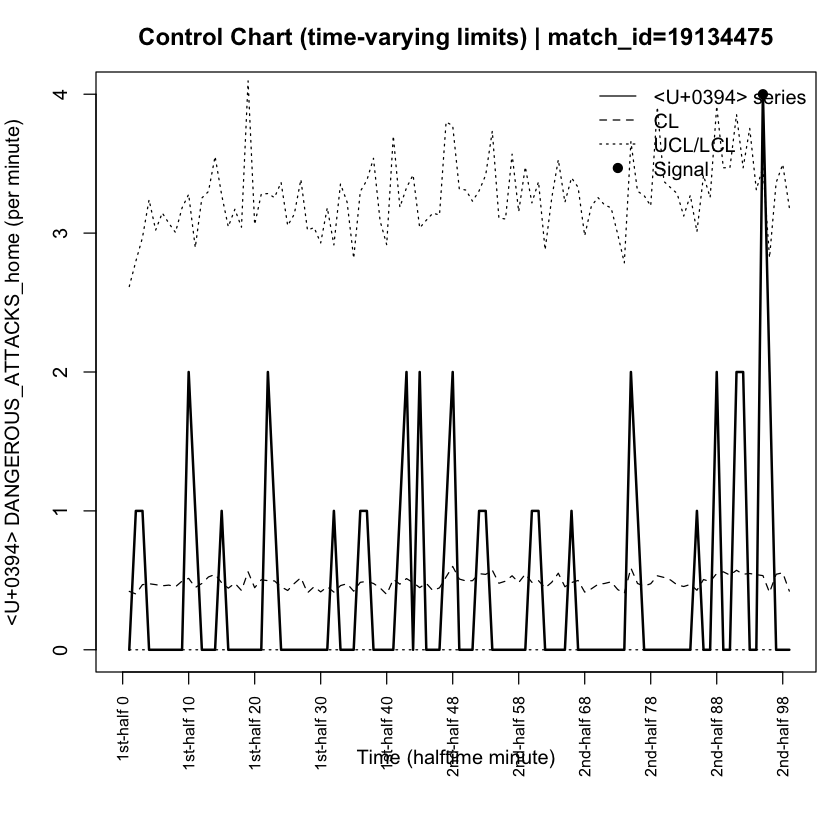

In [4]:
average_profile <- function(df, col = "DANGEROUS_ATTACKS_home") {
  df <- df[order(df$match_id, df$halftime, df$minute), ]
  df$xdiff <- ave(df[[col]], df$match_id, FUN = function(x) c(NA, diff(x)))
  df$xdiff[df$xdiff < 0] <- 0

  agg_mean <- aggregate(xdiff ~ halftime + minute, df, mean, na.rm = TRUE)
  agg_sd   <- aggregate(xdiff ~ halftime + minute, df, sd,   na.rm = TRUE)
  prof <- merge(agg_mean, agg_sd, by = c("halftime", "minute"),
                suffixes = c("_mean", "_sd"))

  # Control limits (3-sigma by default; you can change k later)
  prof
}

plot_match_control_chart <- function(df_all, match_id_to_plot,
                                     col = "DANGEROUS_ATTACKS_home",
                                     k = 3) {
  # Baseline profile across all matches
  prof <- average_profile(df_all, col = col)
  prof$CL  <- prof$xdiff_mean
  prof$UCL <- prof$xdiff_mean + k * prof$xdiff_sd
  prof$LCL <- pmax(0, prof$xdiff_mean - k * prof$xdiff_sd)

  # Extract match and compute its diffs
  df_m <- subset(df_all, match_id == match_id_to_plot)
  df_m <- df_m[order(df_m$halftime, df_m$minute), ]
  df_m$xdiff <- c(NA, diff(df_m[[col]]))
  df_m$xdiff[df_m$xdiff < 0] <- 0

  # Join limits by halftime+minute
  df_plot <- merge(df_m, prof[, c("halftime", "minute", "CL", "UCL", "LCL")],
                   by = c("halftime", "minute"), all.x = TRUE)
  df_plot <- df_plot[order(df_plot$halftime, df_plot$minute), ]

  # Signals: outside limits (when limits exist)
  ok <- is.finite(df_plot$xdiff) & is.finite(df_plot$UCL) & is.finite(df_plot$LCL)
  df_plot$signal <- FALSE
  df_plot$signal[ok] <- (df_plot$xdiff[ok] > df_plot$UCL[ok]) |
                        (df_plot$xdiff[ok] < df_plot$LCL[ok])

  # Plot
  n <- nrow(df_plot)
  time_label <- paste(df_plot$halftime, df_plot$minute, sep = " ")
  op <- par(mar = c(7, 4, 3, 1))

  plot(df_plot$xdiff, type = "l", lwd = 2, xaxt = "n",
       xlab = "Time (halftime minute)",
       ylab = paste0("Δ ", col, " (per minute)"),
       main = paste0("Control Chart (time-varying limits) | match_id=", match_id_to_plot))

  axis(1, at = seq(1, n, by = max(1, floor(n / 10))),
       labels = time_label[seq(1, n, by = max(1, floor(n / 10)))],
       las = 2, cex.axis = 0.8)

  lines(df_plot$CL,  lty = 2)
  lines(df_plot$UCL, lty = 3)
  lines(df_plot$LCL, lty = 3)

  points(which(df_plot$signal), df_plot$xdiff[df_plot$signal], pch = 19)
  legend("topright",
         legend = c("Δ series", "CL", "UCL/LCL", "Signal"),
         lty = c(1, 2, 3, NA), pch = c(NA, NA, NA, 19),
         bty = "n")
  par(op)

  # Return data with limits + signals (useful for debugging)
  df_plot
}
# data = your full data frame
plot_df <- plot_match_control_chart(data, match_id_to_plot = 19134475)

# See where it signaled:
subset(plot_df, signal == TRUE, select = c(match_id, halftime, minute, xdiff, LCL, UCL))


Global limits from all matches (pooled), then plot one match

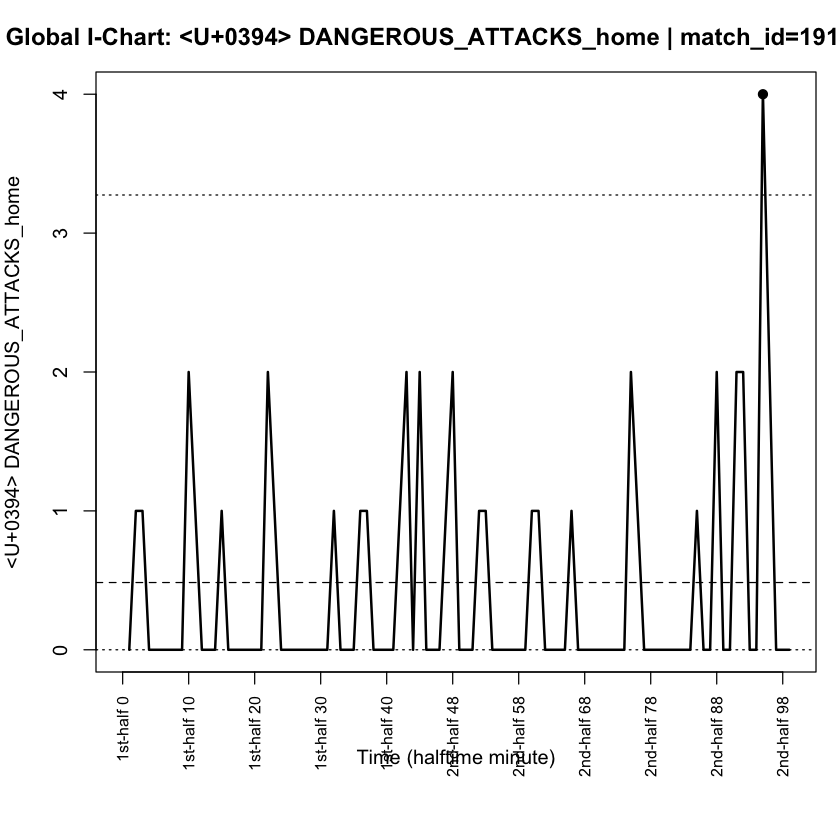

In [5]:
# --- 1) Build pooled per-minute increments across ALL matches
build_global_baseline <- function(df, col = "DANGEROUS_ATTACKS_home") {
  # Ensure time order within match
  df <- df[order(df$match_id, df$halftime, df$minute), ]

  # compute diff per match
  xdiff <- ave(df[[col]], df$match_id, FUN = function(x) c(NA, diff(x)))
  xdiff[xdiff < 0] <- 0  # safety
  xdiff <- xdiff[is.finite(xdiff)]  # drop NA

  mu <- mean(xdiff)
  s  <- sd(xdiff)
  list(mu = mu, s = s)
}

# --- 2) Plot one match using global limits
plot_match_with_global_limits <- function(df_match, baseline, col = "DANGEROUS_ATTACKS_home", k = 3) {
  df_match <- df_match[order(df_match$halftime, df_match$minute), ]
  xdiff <- c(NA, diff(df_match[[col]]))
  xdiff[xdiff < 0] <- 0

  CL  <- baseline$mu
  UCL <- baseline$mu + k * baseline$s
  LCL <- max(0, baseline$mu - k * baseline$s)

  signal <- is.finite(xdiff) & (xdiff > UCL | xdiff < LCL)

  time_label <- paste(df_match$halftime, df_match$minute, sep=" ")
  n <- length(xdiff)

  op <- par(mar=c(7,4,3,1))
  plot(xdiff, type="l", lwd=2, xaxt="n",
       main=paste0("Global I-Chart: Δ ", col, " | match_id=", unique(df_match$match_id)),
       xlab="Time (halftime minute)", ylab=paste0("Δ ", col))
  axis(1, at=seq(1,n,by=max(1,floor(n/10))),
       labels=time_label[seq(1,n,by=max(1,floor(n/10)))],
       las=2, cex.axis=0.8)

  abline(h=CL,  lty=2)
  abline(h=UCL, lty=3)
  abline(h=LCL, lty=3)
  points(which(signal), xdiff[signal], pch=19)
  par(op)

  invisible(list(xdiff=xdiff, CL=CL, UCL=UCL, LCL=LCL, signal=signal))
}

# =========================
# Example usage:
baseline <- build_global_baseline(data)
m_id <- 19134475
df_m <- subset(data, match_id == m_id)
plot_match_with_global_limits(df_m, baseline)


Dangerous attacts tried


In [ ]:
# =========================
# 0) Helpers
# =========================

# Convert halftime to sortable numeric
half_to_num <- function(h) {
  ifelse(h == "1st-half", 1L,
         ifelse(h == "2nd-half", 2L, NA_integer_))
}

# Compute per-minute increment of a cumulative column, per match
add_diff_per_match <- function(df, col) {
  df <- df[order(df$match_id, half_to_num(df$halftime), df$minute), ]
  df$xdiff <- ave(df[[col]], df$match_id, FUN = function(x) c(NA, diff(x)))
  df$xdiff[df$xdiff < 0] <- 0  # safety
  df
}

# Create "true goal at this minute" from cumulative goals (home+away)
add_true_goal_flags <- function(df) {
  df <- df[order(df$match_id, half_to_num(df$halftime), df$minute), ]
  total_goals <- df$GOALS_home + df$GOALS_away
  df$goal_now <- ave(total_goals, df$match_id, FUN = function(x) {
    gdiff <- c(NA, diff(x))
    as.integer(!is.na(gdiff) & gdiff > 0)
  })
  df
}
first_difference <- function(x) {
  c(NA, diff(x))
}

online_mean_variance <- function(x, start_idx, end_idx) {
  # uses x[start_idx:end_idx] excluding NAs
  if (end_idx < start_idx) return(list(mean = NA_real_, variance = NA_real_))
  data_used <- x[start_idx:end_idx]
  data_used <- data_used[is.finite(data_used)]
  if (length(data_used) < 2) return(list(mean = NA_real_, variance = NA_real_))
  list(mean = mean(data_used), variance = var(data_used))
}

# Online control limits from past diffs up to t-2, and evaluate xdiff at t-1
# Predict goal at time t if xdiff(t-1) is out of control
predict_next_goal_from_control <- function(df_match,
                                          k = 3,
                                          warmup = 10,
                                          cooldown = 5) {
  df_match <- df_match[order(half_to_num(df_match$halftime), df_match$minute), ]
  n <- nrow(df_match)

  # Need these columns
  if (!("PASSES_home" %in% names(df_match)) || !("PASSES_away" %in% names(df_match))) {
    df_match$CL <- df_match$UCL <- df_match$LCL <- NA_real_
    df_match$ooc_now <- FALSE
    df_match$pred_goal_now <- 0L
    df_match$signal_value <- NA_real_
    return(df_match)
  }

  # Build the same signal series your predict() uses:
  cum_passes <- df_match$PASSES_home
  diff_passes <- first_difference(cum_passes)
  diff_passes[diff_passes < 0] <- 0  # safety

  CL  <- rep(NA_real_, n)
  UCL <- rep(NA_real_, n)
  LCL <- rep(NA_real_, n)
  ooc <- rep(FALSE, n)            # out-of-control at minute i
  pred_goal_now <- rep(0L, n)     # prediction for THIS minute
  last_warning_i <- NA_integer_

  # i corresponds to current minute index in this match
  for (i in 2:n) {
    # Warmup: do nothing in early minutes
    if (i <= warmup) next

    # Cooldown
    if (!is.na(last_warning_i) && (i - last_warning_i) < cooldown) next

    # Your predict() computed stats from indices 2..(t-1), then checked diff[t]
    # Here: for each i, compute baseline from 2..(i-1) and check diff_passes[i]
    stats <- online_mean_variance(
      x = diff_passes,
      start_idx = 2,
      end_idx = i - 1
    )
    if (!is.finite(stats$variance) || stats$variance <= 0) next
    if (!is.finite(diff_passes[i])) next

    mu <- stats$mean
    s  <- sqrt(stats$variance)

    CL[i]  <- mu
    UCL[i] <- mu + k * s
    LCL[i] <- max(0, mu - k * s)

    ooc[i] <- diff_passes[i] > UCL[i]  # (your code only used upper limit)

    # If minute i is OOC, then predict goal at minute i+1
    if (ooc[i] && i < n) {
      pred_goal_now[i + 1] <- 1L
      last_warning_i <- i
    }
  }

  df_match$signal_value <- diff_passes
  df_match$CL <- CL
  df_match$UCL <- UCL
  df_match$LCL <- LCL
  df_match$ooc_now <- ooc
  df_match$pred_goal_now <- pred_goal_now
  df_match
}


# Plot control chart for one match
plot_control_chart_match <- function(df_match,
                                     col_label = "Δ (PASSES home) per minute") {
  df_match <- df_match[order(half_to_num(df_match$halftime), df_match$minute), ]
  n <- nrow(df_match)
  time_label <- paste(df_match$halftime, df_match$minute, sep = " ")

  y <- df_match$signal_value  # diff_passes

  op <- par(mar = c(7, 4, 3, 1))
  plot(y, type = "l", lwd = 2, xaxt = "n",
       xlab = "Time (halftime minute)",
       ylab = col_label,
       main = paste0("Online Control Chart | match_id=", unique(df_match$match_id)))

  axis(1, at = seq(1, n, by = max(1, floor(n / 10))),
       labels = time_label[seq(1, n, by = max(1, floor(n / 10)))],
       las = 2, cex.axis = 0.8)

  lines(df_match$CL,  lty = 2)
  lines(df_match$UCL, lty = 3)
  lines(df_match$LCL, lty = 3)

  # OOC points (minute i)
  points(which(df_match$ooc_now), y[df_match$ooc_now], pch = 19)

  # Predicted goal minutes (minute i)
  points(which(df_match$pred_goal_now == 1L), y[df_match$pred_goal_now == 1L], pch = 17)

  legend("topright",
         legend = c("Δ passes", "CL", "UCL/LCL", "OOC minute", "Predicted goal minute"),
         lty = c(1, 2, 3, NA, NA),
         pch = c(NA, NA, NA, 19, 17),
         bty = "n")
  par(op)
}


# =========================
# 1) Train/Test split (by match_id)
# =========================

split_by_match <- function(df, test_frac = 0.3, seed = 42) {
  set.seed(seed)
  mids <- unique(df$match_id)
  test_mids <- sample(mids, size = ceiling(length(mids) * test_frac))
  list(
    train = df[df$match_id %in% setdiff(mids, test_mids), ],
    test  = df[df$match_id %in% test_mids, ]
  )
}

# =========================
# 2) Main pipeline
# =========================

run_pipeline <- function(data,
                         col_cum = "DANGEROUS_ATTACKS_home",
                         k = 3,
                         min_base = 10,
                         test_frac = 0.3,
                         seed = 42,
                         plot_match_id = NULL) {

  # split
  sp <- split_by_match(data, test_frac = test_frac, seed = seed)
  train <- sp$train
  test  <- sp$test

  # add diffs + true goal flags to both
  train <- add_true_goal_flags(train)
  test  <- add_true_goal_flags(test)
  test <- do.call(rbind, lapply(split(test, test$match_id), function(df_m) {
  predict_next_goal_from_control(df_m, k = k, warmup = 15, cooldown = 3)
}))

# cool down:


  # Apply the "online control" prediction rule to each match in TEST
  # (Your rule is per-match using past minutes in that match)

  # Build the per-minute evaluation table for all test matches
  eval_table <- test[, c("match_id","halftime","minute",
                      "signal_value","CL","UCL","LCL",
                      "ooc_now","pred_goal_now","goal_now")]
  eval_table$correct <- as.integer(eval_table$pred_goal_now == eval_table$goal_now)


  # overall metrics on test (simple)
  TP <- sum(eval_table$pred_goal_now == 1L & eval_table$goal_now == 1L, na.rm = TRUE)
  FP <- sum(eval_table$pred_goal_now == 1L & eval_table$goal_now == 0L, na.rm = TRUE)
  FN <- sum(eval_table$pred_goal_now == 0L & eval_table$goal_now == 1L, na.rm = TRUE)

  precision <- if ((TP + FP) > 0) TP / (TP + FP) else NA_real_
  recall    <- if ((TP + FN) > 0) TP / (TP + FN) else NA_real_

  # Optional: plot one match (from test by default)
    # Optional: plot one match (from test by default)
  if (is.null(plot_match_id) || !(plot_match_id %in% unique(test$match_id))) {
    plot_match_id <- unique(test$match_id)[1]
    message("plot_match_id not in TEST; plotting match_id=", plot_match_id)
  }

  df_plot <- test[test$match_id == plot_match_id, ]

  # Guard: if no finite xdiff, skip plot
  if (nrow(df_plot) < 3 || all(!is.finite(df_plot$xdiff))) {
    message("Skipping plot: not enough finite xdiff values for match_id=", plot_match_id)
  } else {
    plot_control_chart_match(df_plot, col_label = paste0("Δ ", col_cum, " (per minute)"))
  }


  list(
    train = train,
    test = test,
    eval_table = eval_table,
    metrics = list(TP = TP, FP = FP, FN = FN, precision = precision, recall = recall),
    plotted_match_id = plot_match_id
  )
}

# =========================
# 3) How to run
# =========================
result <- run_pipeline(data, col_cum="DANGEROUS_ATTACKS_home", k=3, min_base=10,
                        test_frac=0.3, seed=42, plot_match_id=19134475)
#
result$metrics
#
# See minutes where prediction was correct for the plotted match:
subset(result$eval_table,
       pred_goal_now == 1L,
       select = c(match_id, halftime, minute, pred_goal_now, goal_now, correct, signal_value, UCL, LCL))

#
# Or see all "true positives" across test:
subset(result$eval_table,
       pred_goal_now == 1L & goal_now == 1L,
       select = c(match_id, halftime, minute, signal_value, UCL))



plot_match_id not in TEST; plotting match_id=19095232

Skipping plot: not enough finite xdiff values for match_id=19095232



$TP
[1] 0

$FP
[1] 0

$FN
[1] 433

$precision
[1] NA

$recall
[1] 0

match_id,halftime,minute,pred_goal_now,goal_now,correct,signal_value,UCL,LCL
<int>,<chr>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>


match_id,halftime,minute,signal_value,UCL
<int>,<chr>,<int>,<dbl>,<dbl>


In [ ]:
df_one <- subset(data, match_id == 19134475)

df_one <- df_one[order(half_to_num(df_one$halftime), df_one$minute), ]

summary(diff(df_one$KEY_PASSES_home))
any(diff(df_one$KEY_PASSES_home) < 0, na.rm = TRUE)


Length  Class   Mode 
     0   NULL   NULL 

[1] FALSE

key_passes with EWMA:

Warning message in min(x):
"min icin eksik olmayan arg"uman yok; Inf d"ond"ur"ul"uyor"
Warning message in max(x):
"max icin eksik olmayan arg"uman yok; -Inf d"ond"ur"ul"uyor"


ERROR: Error in plot.window(...): sonlu 'ylim' degerleri gerekli


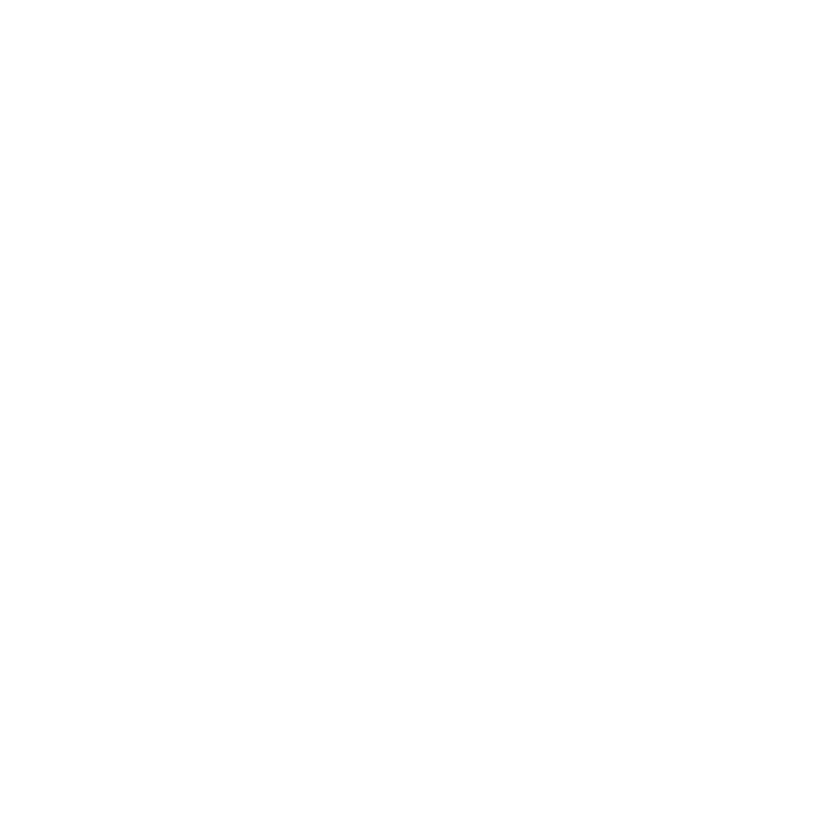

In [8]:
plot_control_chart_match <- function(df_match,
                                     col_label = "Δ (PASSES home+away) per minute") {
  df_match <- df_match[order(half_to_num(df_match$halftime), df_match$minute), ]
  n <- nrow(df_match)
  time_label <- paste(df_match$halftime, df_match$minute, sep = " ")

  y <- df_match$signal_value  # diff_passes

  op <- par(mar = c(7, 4, 3, 1))
  plot(y, type = "l", lwd = 2, xaxt = "n",
       xlab = "Time (halftime minute)",
       ylab = col_label,
       main = paste0("Online Control Chart | match_id=", unique(df_match$match_id)))

  axis(1, at = seq(1, n, by = max(1, floor(n / 10))),
       labels = time_label[seq(1, n, by = max(1, floor(n / 10)))],
       las = 2, cex.axis = 0.8)

  lines(df_match$CL,  lty = 2)
  lines(df_match$UCL, lty = 3)
  lines(df_match$LCL, lty = 3)

  # OOC points (minute i)
  ooc_idx <- which(df_match$ooc_now)
  points(ooc_idx, y[ooc_idx], pch = 19)

  # Predicted goal minutes (minute i)
  pred_idx <- which(df_match$pred_goal_now == 1L)
  points(pred_idx, y[pred_idx], pch = 17)

  # TRUE goal minutes (minute i) -> show as X
  goal_idx <- which(df_match$goal_now == 1L)
  points(goal_idx, y[goal_idx], pch = 4, lwd = 2)

  legend("topright",
         legend = c("Δ passes", "CL", "UCL/LCL", "OOC minute", "Predicted goal", "True goal"),
         lty = c(1, 2, 3, NA, NA, NA),
         pch = c(NA, NA, NA, 19, 17, 4),
         bty = "n")
  par(op)
}

df_plot <- subset(result$test, match_id == result$plotted_match_id)
plot_control_chart_match(df_plot)


key passes

plot_match_id not in TEST; plotting match_id=19095232

Skipping plot: not enough finite xdiff values for match_id=19095232



$TP
[1] 0

$FP
[1] 0

$FN
[1] 2107

$precision
[1] NA

$recall
[1] 0

match_id,halftime,minute,pred_goal_now,goal_now,correct,signal_value,UCL,LCL
<int>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>


match_id,halftime,minute,signal_value,UCL
<int>,<chr>,<int>,<dbl>,<dbl>


Warning message in min(x):
"no non-missing arguments to min; returning Inf"
Warning message in max(x):
"no non-missing arguments to max; returning -Inf"


ERROR: Error in plot.window(...): need finite 'ylim' values


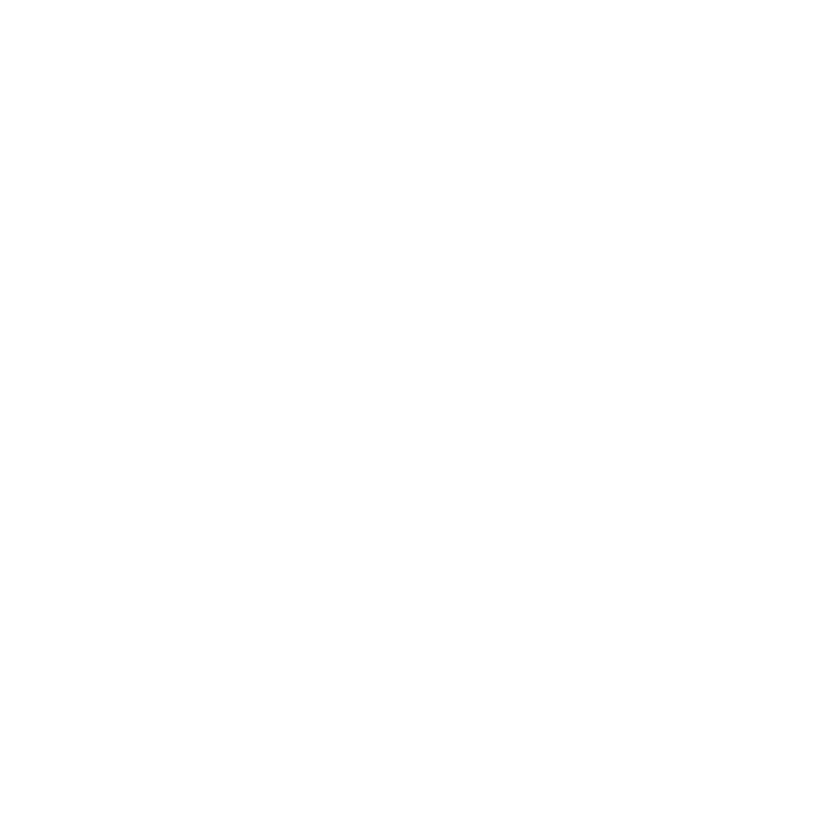

In [ ]:
# =========================
# 0) Helpers
# =========================

# Convert halftime to sortable numeric
half_to_num <- function(h) {
  ifelse(h == "1st-half", 1L,
         ifelse(h == "2nd-half", 2L, NA_integer_))
}

# Compute per-minute increment of a cumulative column, per match
add_diff_per_match <- function(df, col) {
  df <- df[order(df$match_id, half_to_num(df$halftime), df$minute), ]
  df$xdiff <- ave(df[[col]], df$match_id, FUN = function(x) c(NA, diff(x)))
  df$xdiff[df$xdiff < 0] <- 0  # safety
  df
}

# Create "true goal at this minute" from cumulative goals (home+away)
add_true_goal_flags <- function(df, horizon = 5) {

  df <- df[order(df$match_id, half_to_num(df$halftime), df$minute), ]

  total_goals <- df$GOALS_home + df$GOALS_away

  # Step 1: detect exact goal minutes
  goal_minute <- ave(total_goals, df$match_id, FUN = function(x) {
    gdiff <- c(NA, diff(x))
    as.integer(!is.na(gdiff) & gdiff > 0)
  })

  # Step 2: future-looking label
  df$goal_now <- ave(goal_minute, df$match_id, FUN = function(x) {
    n <- length(x)
    sapply(seq_len(n), function(i) {
      end <- min(n, i + horizon)
      as.integer(any(x[(i + 1):end] == 1, na.rm = TRUE))
    })
  })

  df
}

first_difference <- function(x) {
  c(NA, diff(x))
}

online_mean_variance <- function(x, start_idx, end_idx) {
  # uses x[start_idx:end_idx] excluding NAs
  if (end_idx < start_idx) return(list(mean = NA_real_, variance = NA_real_))
  data_used <- x[start_idx:end_idx]
  data_used <- data_used[is.finite(data_used)]
  if (length(data_used) < 2) return(list(mean = NA_real_, variance = NA_real_))
  list(mean = mean(data_used), variance = var(data_used))
}

# Online control limits from past diffs up to t-2, and evaluate xdiff at t-1
# Predict goal at time t if xdiff(t-1) is out of control
predict_next_goal_from_control <- function(df_match,
                                          k = 3,
                                          warmup = 10,
                                          cooldown = 5) {
  df_match <- df_match[order(half_to_num(df_match$halftime), df_match$minute), ]
  n <- nrow(df_match)

  # Need these columns
  if (!("KEY_PASSES_home" %in% names(df_match)) || !("KEY_PASSES_away" %in% names(df_match))) {
    df_match$CL <- df_match$UCL <- df_match$LCL <- NA_real_
    df_match$ooc_now <- FALSE
    df_match$pred_goal_now <- 0L
    df_match$signal_value <- NA_real_
    return(df_match)
  }

  # Build the same signal series your predict() uses:
  cum_passes <- df_match$KEY_PASSES_home
  diff_passes <- first_difference(cum_passes)
  diff_passes[diff_passes < 0] <- 0  # safety

  CL  <- rep(NA_real_, n)
  UCL <- rep(NA_real_, n)
  LCL <- rep(NA_real_, n)
  ooc <- rep(FALSE, n)            # out-of-control at minute i
  pred_goal_now <- rep(0L, n)     # prediction for THIS minute
  last_warning_i <- NA_integer_

  # i corresponds to current minute index in this match
  for (i in 2:n) {
    # Warmup: do nothing in early minutes
    if (i <= warmup) next

    # Cooldown
    if (!is.na(last_warning_i) && (i - last_warning_i) < cooldown) next

    # Your predict() computed stats from indices 2..(t-1), then checked diff[t]
    # Here: for each i, compute baseline from 2..(i-1) and check diff_passes[i]
    stats <- online_mean_variance(
      x = diff_passes,
      start_idx = 2,
      end_idx = i - 1
    )
    if (!is.finite(stats$variance) || stats$variance <= 0) next
    if (!is.finite(diff_passes[i])) next

    mu <- stats$mean
    s  <- sqrt(stats$variance)

    CL[i]  <- mu
    UCL[i] <- mu + k * s
    LCL[i] <- max(0, mu - k * s)

    ooc[i] <- diff_passes[i] > UCL[i]  # (your code only used upper limit)

    # If minute i is OOC, then predict goal at minute i+1
    ooc_streak <- 0

    for (i in 2:n) {
      ...
      if (ooc[i]) {
        ooc_streak <- ooc_streak + 1
      } else {
        ooc_streak <- 0
      }

      if (ooc_streak >= 2 && i < n) {
        pred_goal_now[i + 1] <- 1L
        last_warning_i <- i
        ooc_streak <- 0
      }
    }

  }

  df_match$signal_value <- diff_passes
  df_match$CL <- CL
  df_match$UCL <- UCL
  df_match$LCL <- LCL
  df_match$ooc_now <- ooc
  df_match$pred_goal_now <- pred_goal_now
  df_match
}


# Plot control chart for one match
plot_control_chart_match <- function(df_match,
                                     col_label = "Δ (KEY_PASSES home) per minute") {
  df_match <- df_match[order(half_to_num(df_match$halftime), df_match$minute), ]
  n <- nrow(df_match)
  time_label <- paste(df_match$halftime, df_match$minute, sep = " ")

  y <- df_match$signal_value  # diff_passes

  op <- par(mar = c(7, 4, 3, 1))
  plot(y, type = "l", lwd = 2, xaxt = "n",
       xlab = "Time (halftime minute)",
       ylab = col_label,
       main = paste0("Online Control Chart | match_id=", unique(df_match$match_id)))

  axis(1, at = seq(1, n, by = max(1, floor(n / 10))),
       labels = time_label[seq(1, n, by = max(1, floor(n / 10)))],
       las = 2, cex.axis = 0.8)

  lines(df_match$CL,  lty = 2)
  lines(df_match$UCL, lty = 3)
  lines(df_match$LCL, lty = 3)

  # OOC points (minute i)
  points(which(df_match$ooc_now), y[df_match$ooc_now], pch = 19)

  # Predicted goal minutes (minute i)
  points(which(df_match$pred_goal_now == 1L), y[df_match$pred_goal_now == 1L], pch = 17)

  legend("topright",
         legend = c("Δ key passes", "CL", "UCL/LCL", "OOC minute", "Predicted goal minute"),
         lty = c(1, 2, 3, NA, NA),
         pch = c(NA, NA, NA, 19, 17),
         bty = "n")
  par(op)
}


# =========================
# 1) Train/Test split (by match_id)
# =========================

split_by_match <- function(df, test_frac = 0.3, seed = 42) {
  set.seed(seed)
  mids <- unique(df$match_id)
  test_mids <- sample(mids, size = ceiling(length(mids) * test_frac))
  list(
    train = df[df$match_id %in% setdiff(mids, test_mids), ],
    test  = df[df$match_id %in% test_mids, ]
  )
}

# =========================
# 2) Main pipeline
# =========================

run_pipeline <- function(data,
                         k = 3,
                         min_base = 10,
                         test_frac = 0.3,
                         seed = 42,
                         plot_match_id = NULL) {

  # split
  sp <- split_by_match(data, test_frac = test_frac, seed = seed)
  train <- sp$train
  test  <- sp$test

  # add diffs + true goal flags to both
  train <- add_true_goal_flags(train)
  test  <- add_true_goal_flags(test)
  test <- do.call(rbind, lapply(split(test, test$match_id), function(df_m) {
  predict_next_goal_from_control(df_m, k = k, warmup = 15, cooldown = 3)
}))

# cool down:


  # Apply the "online control" prediction rule to each match in TEST
  # (Your rule is per-match using past minutes in that match)

  # Build the per-minute evaluation table for all test matches
  eval_table <- test[, c("match_id","halftime","minute",
                      "signal_value","CL","UCL","LCL",
                      "ooc_now","pred_goal_now","goal_now")]
  eval_table$correct <- as.integer(eval_table$pred_goal_now == eval_table$goal_now)


  # overall metrics on test (simple)
  TP <- sum(eval_table$pred_goal_now == 1L & eval_table$goal_now == 1L, na.rm = TRUE)
  FP <- sum(eval_table$pred_goal_now == 1L & eval_table$goal_now == 0L, na.rm = TRUE)
  FN <- sum(eval_table$pred_goal_now == 0L & eval_table$goal_now == 1L, na.rm = TRUE)

  precision <- if ((TP + FP) > 0) TP / (TP + FP) else NA_real_
  recall    <- if ((TP + FN) > 0) TP / (TP + FN) else NA_real_

  # Optional: plot one match (from test by default)
    # Optional: plot one match (from test by default)
  if (is.null(plot_match_id) || !(plot_match_id %in% unique(test$match_id))) {
    plot_match_id <- unique(test$match_id)[1]
    message("plot_match_id not in TEST; plotting match_id=", plot_match_id)
  }

  df_plot <- test[test$match_id == plot_match_id, ]

  # Guard: if no finite xdiff, skip plot
  if (nrow(df_plot) < 3 || all(!is.finite(df_plot$xdiff))) {
    message("Skipping plot: not enough finite xdiff values for match_id=", plot_match_id)
  } else {
    plot_control_chart_match(df_plot, col_label = paste0("Δ ", col_cum, " (per minute)"))
  }


  list(
    train = train,
    test = test,
    eval_table = eval_table,
    metrics = list(TP = TP, FP = FP, FN = FN, precision = precision, recall = recall),
    plotted_match_id = plot_match_id
  )
}

# =========================
# 3) How to run
# =========================
result <- run_pipeline(data, k=3, min_base=10,
                        test_frac=0.3, seed=42, plot_match_id=19134475)
#
result$metrics
#
# See minutes where prediction was correct for the plotted match:
subset(result$eval_table,
       pred_goal_now == 1L,
       select = c(match_id, halftime, minute, pred_goal_now, goal_now, correct, signal_value, UCL, LCL))

#
# Or see all "true positives" across test:
subset(result$eval_table,
       pred_goal_now == 1L & goal_now == 1L,
       select = c(match_id, halftime, minute, signal_value, UCL))

plot_control_chart_match <- function(df_match,
                                     col_label = "(key PASSES home+away) per minute") {
  df_match <- df_match[order(half_to_num(df_match$halftime), df_match$minute), ]
  n <- nrow(df_match)
  time_label <- paste(df_match$halftime, df_match$minute, sep = " ")

  y <- df_match$signal_value  # diff_passes

  op <- par(mar = c(7, 4, 3, 1))
  plot(y, type = "l", lwd = 2, xaxt = "n",
       xlab = "Time (halftime minute)",
       ylab = col_label,
       main = paste0("Online Control Chart | match_id=", unique(df_match$match_id)))

  axis(1, at = seq(1, n, by = max(1, floor(n / 10))),
       labels = time_label[seq(1, n, by = max(1, floor(n / 10)))],
       las = 2, cex.axis = 0.8)

  lines(df_match$CL,  lty = 2)
  lines(df_match$UCL, lty = 3)
  lines(df_match$LCL, lty = 3)

  # OOC points (minute i)
  ooc_idx <- which(df_match$ooc_now)
  points(ooc_idx, y[ooc_idx], pch = 19)

  # Predicted goal minutes (minute i)
  pred_idx <- which(df_match$pred_goal_now == 1L)
  points(pred_idx, y[pred_idx], pch = 17)

  # TRUE goal minutes (minute i) -> show as X
  goal_idx <- which(df_match$goal_now == 1L)
  points(goal_idx, y[goal_idx], pch = 4, lwd = 2)

  legend("topright",
         legend = c(" passes", "CL", "UCL/LCL", "OOC minute", "Predicted goal", "True goal"),
         lty = c(1, 2, 3, NA, NA, NA),
         pch = c(NA, NA, NA, 19, 17, 4),
         bty = "n")
  par(op)
}

df_plot <- subset(result$test, match_id == result$plotted_match_id)
plot_control_chart_match(df_plot)


In [6]:
# =========================
# 0) Helpers
# =========================

half_to_num <- function(h) {
  ifelse(h == "1st-half", 1L,
         ifelse(h == "2nd-half", 2L, NA_integer_))
}

first_difference <- function(x) {
  c(NA, diff(x))
}

online_mean_variance <- function(x, start_idx, end_idx) {
  if (end_idx < start_idx) return(list(mean = NA_real_, variance = NA_real_))
  z <- x[start_idx:end_idx]
  z <- z[is.finite(z)]
  if (length(z) < 2) return(list(mean = NA_real_, variance = NA_real_))
  list(mean = mean(z), variance = var(z))
}

# =========================
# 1) FUTURE GOAL LABEL (paper-safe)
# =========================

add_true_goal_flags <- function(df, horizon = 5) {

  df <- df[order(df$match_id, half_to_num(df$halftime), df$minute), ]

  total_goals <- df$GOALS_home + df$GOALS_away

  goal_minute <- ave(total_goals, df$match_id, FUN = function(x) {
    d <- c(NA, diff(x))
    as.integer(!is.na(d) & d > 0)
  })

  df$goal_now <- ave(goal_minute, df$match_id, FUN = function(x) {
    n <- length(x)
    sapply(seq_len(n), function(i) {
      end <- min(n, i + horizon)
      as.integer(any(x[(i + 1):end] == 1))
    })
  })

  df
}

# =========================
# 2) ONLINE CONTROL + FUTURE WARNING WINDOW
# =========================

predict_next_goal_from_control <- function(df_match,
                                           k = 3,
                                           warmup = 15,
                                           horizon = 5,
                                           streak_need = 4,
                                           cooldown = 5, base_window = 10) {

  df_match <- df_match[order(half_to_num(df_match$halftime), df_match$minute), ]
  n <- nrow(df_match)

  cum <- df_match$DANGEROUS_ATTACKS_home + df_match$DANGEROUS_ATTACKS_away
  diff_sig <- first_difference(cum)
  diff_sig[diff_sig < 0] <- 0

  CL <- UCL <- LCL <- rep(NA_real_, n)
  ooc <- rep(FALSE, n)
  pred_goal_now <- rep(0L, n)

  last_warning_i <- NA_integer_
  ooc_streak <- 0L

  for (i in 2:n) {

    if (i <= warmup) next
    if (!is.na(last_warning_i) && (i - last_warning_i) < cooldown) next

    start_idx <- max(2, i - base_window)
    stats <- online_mean_variance(diff_sig, start_idx, i - 1)
    if (!is.finite(stats$variance) || stats$variance <= 0) next
    if (!is.finite(diff_sig[i])) next

    mu <- stats$mean
    s  <- sqrt(stats$variance)

    CL[i]  <- mu
    UCL[i] <- mu + k * s
    LCL[i] <- max(0, mu - k * s)

    ooc[i] <- diff_sig[i] > UCL[i]

    if (ooc[i]) {
      ooc_streak <- ooc_streak + 1L
    } else {
      ooc_streak <- 0L
    }

    # 🚨 FUTURE WARNING WINDOW (paper-correct)
    if (ooc_streak >= streak_need) {
      for (h in 1:horizon) {
        if (i + h <= n) {
          pred_goal_now[i + h] <- 1L
        }
      }
      last_warning_i <- i
      ooc_streak <- 0L
    }
  }

  df_match$signal_value <- diff_sig
  df_match$CL <- CL
  df_match$UCL <- UCL
  df_match$LCL <- LCL
  df_match$ooc_now <- ooc
  df_match$pred_goal_now <- pred_goal_now

  df_match
}

# =========================
# 3) TRAIN / TEST SPLIT
# =========================

split_by_match <- function(df, test_frac = 0.3, seed = 42) {
  set.seed(seed)
  mids <- unique(df$match_id)
  test_mids <- sample(mids, ceiling(length(mids) * test_frac))
  list(
    train = df[!df$match_id %in% test_mids, ],
    test  = df[df$match_id %in% test_mids, ]
  )
}

# =========================
# 4) MAIN PIPELINE
# =========================

run_pipeline <- function(data,
                         k = 3,
                         horizon = 5,
                         test_frac = 0.3,
                         seed = 42,
                         plot_match_id = NULL) {

  sp <- split_by_match(data, test_frac, seed)
  train <- add_true_goal_flags(sp$train, horizon)
  test  <- add_true_goal_flags(sp$test, horizon)

  test <- do.call(rbind, lapply(split(test, test$match_id), function(df_m) {
    predict_next_goal_from_control(
      df_m,
      k = k,
      horizon = horizon, streak_need = 2,
    )
  }))

  eval_table <- test[, c(
    "match_id","halftime","minute",
    "signal_value","CL","UCL","LCL",
    "ooc_now","pred_goal_now","goal_now"
  )]

  TP <- sum(eval_table$pred_goal_now == 1 & eval_table$goal_now == 1, na.rm = TRUE)
  FP <- sum(eval_table$pred_goal_now == 1 & eval_table$goal_now == 0, na.rm = TRUE)
  FN <- sum(eval_table$pred_goal_now == 0 & eval_table$goal_now == 1, na.rm = TRUE)


  list(
    test = test,
    eval_table = eval_table,
    metrics = list(
      TP = TP,
      FP = FP,
      FN = FN,
      precision = ifelse(TP + FP > 0, TP / (TP + FP), NA),
      recall    = ifelse(TP + FN > 0, TP / (TP + FN), NA)
    )
  )
}

# =========================
# 5) RUN
# =========================

result <- run_pipeline(
  data,
  k = 2,
  horizon = 5,
  test_frac = 0.3,
  seed = 42
)
table(result$test$ooc_now)

result$metrics
table(result$test$pred_goal_now)




FALSE  TRUE 
16569  1289 

$TP
[1] 39

$FP
[1] 309

$FN
[1] 2068

$precision
[1] 0.112069

$recall
[1] 0.01850973


    0     1 
17507   351 

In [7]:
with(result$eval_table, {
  goal_times <- which(goal_now == 1)
  ooc_times  <- which(ooc_now == 1)

  min_dist <- sapply(ooc_times, function(t) {
    min(abs(goal_times - t))
  })

  summary(min_dist)
})


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    4.00   11.00   21.51   27.00  239.00 

In [9]:
# how many predictions & goals?
sum(result$eval_table$pred_goal_now == 1L, na.rm=TRUE)
sum(result$eval_table$goal_now == 1L, na.rm=TRUE)

# do any overlap at the same minute?
sum(result$eval_table$pred_goal_now == 1L & result$eval_table$goal_now == 1L, na.rm=TRUE)

# show predicted minutes vs goal minutes for ONE match
m <- result$plotted_match_id
pred_mins <- subset(result$eval_table, match_id==m & pred_goal_now==1L, select=c(halftime, minute))
goal_mins <- subset(result$eval_table, match_id==m & goal_now==1L, select=c(halftime, minute))
pred_mins; goal_mins


[1] 351

[1] 2107

[1] 39

halftime,minute
<chr>,<int>


halftime,minute
<chr>,<int>
